In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

CI_DIR = Path('/home/users/cornkle/pythonWorkspace/proj_CEH/JASMIN/umbrella_CI/')
YEAR = 2020
DROP_EXACT_DUPLICATES = False

classes = ['aligned', 'right', 'reverse', 'left']

def read_ci_file(path, category):
    df = pd.read_csv(path, sep=r'\s+', header=None,
                     names=['lon', 'lat', 'month', 'day', 'hour'])

    df['category'] = category
    df['time'] = pd.to_datetime(dict(
        year=np.full(len(df), YEAR),
        month=df['month'],
        day=df['day'],
        hour=df['hour']
    ))

    df['exact_duplicate'] = df.duplicated(
        ['lon', 'lat', 'month', 'day', 'hour'], keep=False
    )

    if DROP_EXACT_DUPLICATES:
        df = df.drop_duplicates(
            ['lon', 'lat', 'month', 'day', 'hour']
        ).reset_index(drop=True)

    return df

ci = {
    category: read_ci_file(CI_DIR / f'{category}_CIs.txt', category)
    for category in classes
}

cases = pd.concat(ci.values(), ignore_index=True)

for category, df in ci.items():
    n_unique = len(df.drop_duplicates(['lon', 'lat', 'month', 'day', 'hour']))
    print(f'{category:8s}: {len(df):5d} rows, {n_unique:5d} unique')

display(cases.head())

aligned :  4196 rows,  3431 unique
right   :  4620 rows,  3745 unique
reverse : 10459 rows,  8585 unique
left    :  6856 rows,  5602 unique


,lon,lat,month,day,hour,category,time,exact_duplicate
0,16.558594,-23.554688,4,1,12,aligned,2020-04-01 12:00:00,False
1,20.144531,-22.992188,4,1,12,aligned,2020-04-01 12:00:00,False
2,21.128906,-20.132812,4,1,12,aligned,2020-04-01 12:00:00,False
3,22.042969,-19.945312,4,1,12,aligned,2020-04-01 12:00:00,True
4,22.042969,-19.945312,4,1,12,aligned,2020-04-01 12:00:00,True


In [2]:
import xarray as xr
from pathlib import Path

MODEL_ROOT = Path(
    '/gws/ssde/j25b/kscale/DYAMOND3_reruns/'
    '5km-RAL3p3-tuned/glm/field.pp'
)

RUN_NAME = 'glm.n2560_RAL3p3_tuned'

ANCIL_ROOT = Path('/gws/ssde/j25b/kscale/DYAMOND3_reruns')

TOPO_FILE = ANCIL_ROOT / 'orography/orography-n2560e.nc'
MASK_FILE = ANCIL_ROOT / 'landmask/mask-n2560e.nc'

topo_ds = xr.open_dataset(TOPO_FILE)
mask_ds = xr.open_dataset(MASK_FILE)

In [3]:
topo = topo_ds['surface_altitude'].load().values.astype(float)
landmask = mask_ds['land_binary_mask'].load().values.astype(float)

grid_lat = topo_ds['latitude'].values.astype(float)
grid_lon = topo_ds['longitude'].values.astype(float)

assert topo.shape == landmask.shape
assert np.allclose(grid_lat, mask_ds['latitude'].values)
assert np.allclose(grid_lon, mask_ds['longitude'].values)

print('Shared ancillary grid:', topo.shape)
print('Topography range:', np.nanmin(topo), np.nanmax(topo), 'm')
print('Land-mask values:', np.unique(landmask[np.isfinite(landmask)]))

Shared ancillary grid: (3840, 5120)
Topography range: 0.0 6342.32861328125 m
Land-mask values: [0. 1.]


In [4]:
FILTER_RADIUS_KM = 200

def wrapped_lon_difference(lon, lon0):
    return (lon - lon0 + 180) % 360 - 180

def location_metrics(lon0, lat0, radius_km=200):
    dlat_max = radius_km / 110.574
    dlon_max = radius_km / (
        111.320 * np.cos(np.deg2rad(lat0))
    )

    iy = np.where(np.abs(grid_lat - lat0) <= dlat_max)[0]
    dlon = wrapped_lon_difference(grid_lon, lon0)
    ix = np.where(np.abs(dlon) <= dlon_max)[0]

    if len(iy) == 0 or len(ix) == 0:
        return {
            'central_land': False,
            'water_distance_km': np.nan,
            'topo_mean_200km': np.nan,
            'topo_std_200km': np.nan,
            'topo_relief_200km': np.nan,
            'topo_max_200km': np.nan
        }

    dy = (grid_lat[iy] - lat0) * 110.574
    dx = dlon[ix] * 111.320 * np.cos(np.deg2rad(lat0))
    distance = np.hypot(dy[:, None], dx[None, :])
    inside = distance <= radius_km

    local_topo = topo[np.ix_(iy, ix)]
    local_mask = landmask[np.ix_(iy, ix)]

    central_y = int(np.argmin(np.abs(grid_lat - lat0)))
    central_x = int(np.argmin(np.abs(
        wrapped_lon_difference(grid_lon, lon0)
    )))
    central_land = landmask[central_y, central_x] >= 0.5

    water = inside & (local_mask < 0.5)

    if np.any(water):
        water_distance = np.nanmin(distance[water])
    else:
        water_distance = np.inf

    # Use only finite land elevations for the terrain diagnostics
    valid_topo = (
        inside &
        (local_mask >= 0.5) &
        np.isfinite(local_topo)
    )
    elevation = local_topo[valid_topo]

    if elevation.size:
        p05, p95 = np.nanpercentile(elevation, [5, 95])
        topo_mean = np.nanmean(elevation)
        topo_std = np.nanstd(elevation)
        topo_relief = p95 - p05
        topo_max = np.nanmax(elevation)
    else:
        topo_mean = topo_std = topo_relief = topo_max = np.nan

    return {
        'central_land': central_land,
        'water_distance_km': water_distance,
        'topo_mean_200km': topo_mean,
        'topo_std_200km': topo_std,
        'topo_relief_200km': topo_relief,
        'topo_max_200km': topo_max
    }

In [5]:
CI_HOURS = [14]
LAG_HOURS = -3          # later change to 0, -2 or -3
PL_TIME_METHOD = 'nearest'

work_cases = cases[cases['hour'].isin(CI_HOURS)].copy()
work_cases['sample_time'] = work_cases['time'] + pd.to_timedelta(LAG_HOURS, unit='h')

print(work_cases.groupby(['category', 'hour']).size().unstack(fill_value=0))
display(work_cases.head())

hour        14
category      
aligned    496
left       993
reverse   1828
right      620


,lon,lat,month,day,hour,category,time,exact_duplicate,sample_time
19,25.347656,-29.414062,4,1,14,aligned,2020-04-01 14:00:00,True,2020-04-01 11:00:00
20,25.347656,-29.414062,4,1,14,aligned,2020-04-01 14:00:00,True,2020-04-01 11:00:00
21,25.417969,-28.757812,4,1,14,aligned,2020-04-01 14:00:00,True,2020-04-01 11:00:00
22,25.417969,-28.757812,4,1,14,aligned,2020-04-01 14:00:00,True,2020-04-01 11:00:00
23,25.558594,-27.679688,4,1,14,aligned,2020-04-01 14:00:00,True,2020-04-01 11:00:00


In [6]:
locations = (
    work_cases[['lon', 'lat']]
    .drop_duplicates()
    .reset_index(drop=True)
)

records = []

for number, row in enumerate(locations.itertuples(index=False), start=1):
    metrics = location_metrics(
        float(row.lon), float(row.lat),
        radius_km=FILTER_RADIUS_KM
    )
    metrics['lon'] = float(row.lon)
    metrics['lat'] = float(row.lat)
    records.append(metrics)

    if number % 1000 == 0 or number == len(locations):
        print(f'Processed {number}/{len(locations)} unique locations')

location_metrics_table = pd.DataFrame(records)

work_cases = work_cases.merge(
    location_metrics_table,
    on=['lon', 'lat'],
    how='left'
)

Processed 1000/3305 unique locations
Processed 2000/3305 unique locations
Processed 3000/3305 unique locations
Processed 3305/3305 unique locations


In [7]:
work_cases['coast_ok'] = (
    work_cases['central_land'] &
    (work_cases['water_distance_km'] >= FILTER_RADIUS_KM)
)

coast_summary = work_cases.groupby('category')['coast_ok'].agg(
    retained='sum',
    total='count',
    retained_fraction='mean'
)
coast_summary['retained_percent'] = (
    coast_summary['retained_fraction'] * 100
)

print(coast_summary)

          retained  total  retained_fraction  retained_percent
category                                                      
aligned        470    496           0.947581         94.758065
left           964    993           0.970796         97.079557
reverse       1776   1828           0.971554         97.155361
right          596    620           0.961290         96.129032


In [8]:
threshold_cases = work_cases.drop_duplicates(
    ['category', 'lon', 'lat', 'time']
)

inland_cases = threshold_cases[
    threshold_cases['coast_ok'] &
    np.isfinite(threshold_cases['topo_relief_200km'])
].copy()

topo_columns = [
    'topo_mean_200km',
    'topo_std_200km',
    'topo_relief_200km',
    'topo_max_200km'
]

print(
    inland_cases[topo_columns].describe(
        percentiles=[0.5, 0.75, 0.8, 0.9, 0.95, 0.99]
    )
)

       topo_mean_200km  topo_std_200km  topo_relief_200km  topo_max_200km
count      3237.000000     3237.000000        3237.000000     3237.000000
mean        595.477332      135.779463         429.879990     1096.450875
std         275.701508      120.505723         381.839949      652.500059
min         128.610897        7.417584          24.021036      331.649231
50%         520.972569       98.076755         309.513992      879.622925
75%         671.349454      159.720973         510.388745     1260.175049
80%         721.870663      186.484575         586.854430     1378.970459
90%         922.480921      295.379715         932.492216     1914.700439
95%        1168.152079      392.733222        1272.156887     2276.057617
99%        1715.653116      613.033165        1976.693410     3783.167207
max        2147.004714      902.845353        2746.778151     4053.086182


In [9]:
TOPO_RELIEF_MAX = 700

work_cases['topography_ok'] = (
    np.isfinite(work_cases['topo_relief_200km']) &
    (work_cases['topo_relief_200km'] <= TOPO_RELIEF_MAX)
)

work_cases['sample_ok'] = (
    work_cases['coast_ok'] &
    work_cases['topography_ok']
)

filtered_cases = work_cases[work_cases['sample_ok']].copy()

print(f'Topographic-relief threshold: {TOPO_RELIEF_MAX:.0f} m')
print(f'All cases:      {len(work_cases)}')
print(f'Filtered cases: {len(filtered_cases)}')

Topographic-relief threshold: 700 m
All cases:      3937
Filtered cases: 3206


In [10]:
category_summary = pd.DataFrame({
    'all': work_cases.groupby('category').size(),
    'inland': work_cases[
        work_cases['coast_ok']
    ].groupby('category').size(),
    'inland_low_topo': filtered_cases.groupby('category').size()
}).fillna(0).astype(int)

category_summary['retained_from_inland_%'] = (
    category_summary['inland_low_topo'] /
    category_summary['inland'] * 100
)

print(category_summary)

           all  inland  inland_low_topo  retained_from_inland_%
category                                                       
aligned    496     470              386               82.127660
left       993     964              807               83.713693
reverse   1828    1776             1512               85.135135
right      620     596              501               84.060403


In [116]:
VARIABLES = {
    'q_low': ('apvera.pp', 'm01s03i237'),
    'u10':   ('apvera.pp', 'm01s03i225'),
    'v10':   ('apvera.pp', 'm01s03i226'),
    'olr':   ('apvera.pp', 'm01s02i205'),
    'sm':    ('apverb.pp', 'm01s08i223'),
    'rain':  ('apverb.pp', 'm01s04i203'),
    'u600':  ('apverc.pp', 'm01s15i201'),
    'v600':  ('apverc.pp', 'm01s15i202')
}

CUBE_SELECTOR = {'rain': 'time_mean'}

TIME_METHOD = {
    'q_low': 'exact',
    'u10': 'exact',
    'v10': 'exact',
    'sm': 'exact',
    'rain': 'exact',       # exact interval ending at target time
    'olr': 'nearest',      # output occurs at HH:02
    'u600': 'nearest',
    'v600': 'nearest'
}

MIDLEVEL_PRESSURE_HPA = 600

In [117]:
from functools import lru_cache
import iris
import numpy as np
import pandas as pd

def pp_path(stream, cycle):
    name = stream.removesuffix('.pp')
    stamp = pd.Timestamp(cycle).strftime('%Y%m%dT%H%MZ')
    return MODEL_ROOT / stream / f'{RUN_NAME}.{name}_{stamp}.pp'

def take_coord_index(cube, coord_name, index):
    dim = cube.coord_dims(coord_name)[0]
    selection = [slice(None)] * cube.ndim
    selection[dim] = index
    return cube[tuple(selection)]

def select_vertical_level(cube, variable):
    
    if variable == 'sm':
        depth = cube.coord('depth')
        index = int(np.argmin(depth.points))
        return take_coord_index(cube, 'depth', index)

    if variable in ['u600', 'v600']:
        pressure = cube.coord('pressure')
        pressure.convert_units('hPa')
        index = int(np.argmin(np.abs(pressure.points - MIDLEVEL_PRESSURE_HPA)))

        if not np.isclose(pressure.points[index], MIDLEVEL_PRESSURE_HPA):
            raise ValueError(f'{MIDLEVEL_PRESSURE_HPA} hPa is unavailable')

        return take_coord_index(cube, 'pressure', index)

    return cube


def has_time_mean(cube):
    return any(
        method.method == 'mean' and 'time' in method.coord_names
        for method in cube.cell_methods
    )

@lru_cache(maxsize=40)
def load_base_cube(stream, stash, cycle_string, selector='single'):
    path = pp_path(stream, pd.Timestamp(cycle_string))
    constraint = iris.Constraint(
        cube_func=lambda c: str(c.attributes.get('STASH', '')) == stash
    )
    cubes = list(iris.load(str(path), constraint))

    if selector == 'time_mean':
        cubes = [cube for cube in cubes if has_time_mean(cube)]

    if len(cubes) != 1:
        details = [(cube.shape, cube.cell_methods) for cube in cubes]
        raise ValueError(
            f'Expected one cube for {stash}, selector={selector}; '
            f'found {len(cubes)}: {details}'
        )

    return cubes[0]

def as_timestamp(date):
    return pd.Timestamp(
        date.year, date.month, date.day,
        date.hour, date.minute, date.second
    )

def effective_times(cube, variable):
    time = cube.coord('time')

    # Rainfall means are labelled at the interval midpoint.
    # Use the end of the one-hour interval as their effective time.
    values = time.bounds[:, 1] if variable == 'rain' else time.points
    return [as_timestamp(date) for date in time.units.num2date(values)]

def available_time_slices(variable, target_time):
    stream, stash = VARIABLES[variable]
    selector = CUBE_SELECTOR.get(variable, 'single')
    target_time = pd.Timestamp(target_time)
    current_cycle = target_time.floor('12h')
    cycles = [current_cycle, current_cycle - pd.Timedelta(hours=12)]
    available = {}

    for cycle in cycles:
        path = pp_path(stream, cycle)
        if not path.exists():
            continue

        cube = load_base_cube(stream, stash, str(cycle), selector)
        cube = select_vertical_level(cube, variable)

        for index, valid_time in enumerate(effective_times(cube, variable)):
            available.setdefault(
                valid_time,
                take_coord_index(cube, 'time', index)
            )

    if not available:
        raise FileNotFoundError(
            f'No {variable} data found around {target_time}'
        )

    return available

def load_field_at_time(variable, target_time, method=None):
    target_time = pd.Timestamp(target_time)
    method = TIME_METHOD[variable] if method is None else method
    available = available_time_slices(variable, target_time)
    valid_times = sorted(available)

    if method == 'exact':
        if target_time not in available:
            raise ValueError(
                f'No exact {variable} field at {target_time}; '
                f'available={valid_times}'
            )
        used_time = target_time

    elif method == 'nearest':
        used_time = min(valid_times, key=lambda time: abs(time - target_time))

    else:
        raise ValueError("method must be 'exact' or 'nearest'")

    return available[used_time], used_time

In [139]:
test_case = filtered_cases.iloc[1800]
target_time = test_case['sample_time']

print('CI:', test_case['time'])
print('target:', target_time)
print('category:', test_case['category'])
print('location:', test_case['lon'], test_case['lat'])

test_fields = {}

for variable in VARIABLES:
    cube, used_time = load_field_at_time(variable, target_time)
    test_fields[variable] = cube

    print(
        f'{variable:6s}: method={TIME_METHOD[variable]:7s}, '
        f'target={target_time}, used={used_time}, '
        f'shape={cube.shape}'
    )

CI: 2020-09-12 15:00:00
target: 2020-09-12 12:00:00
category: reverse
location: 3.2695312 8.5546875


/home/users/cornkle/miniforge3/envs/work/lib/python3.14/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


q_low : method=exact  , target=2020-09-12 12:00:00, used=2020-09-12 12:00:00, shape=(3840, 5120)
u10   : method=exact  , target=2020-09-12 12:00:00, used=2020-09-12 12:00:00, shape=(3841, 5120)
v10   : method=exact  , target=2020-09-12 12:00:00, used=2020-09-12 12:00:00, shape=(3841, 5120)
olr   : method=nearest, target=2020-09-12 12:00:00, used=2020-09-12 12:02:00, shape=(3840, 5120)
sm    : method=exact  , target=2020-09-12 12:00:00, used=2020-09-12 12:00:00, shape=(3840, 5120)
rain  : method=exact  , target=2020-09-12 12:00:00, used=2020-09-12 12:00:00, shape=(3840, 5120)


/home/users/cornkle/miniforge3/envs/work/lib/python3.14/site-packages/iris/fileformats/rules.py:382: IrisUserWarning: Unable to create instance of HybridHeightFactory. The source data contains no field(s) for 'orography'.
  warnings.warn(


u600  : method=nearest, target=2020-09-12 12:00:00, used=2020-09-12 12:00:00, shape=(3841, 5120)
v600  : method=nearest, target=2020-09-12 12:00:00, used=2020-09-12 12:00:00, shape=(3841, 5120)


In [140]:
from scipy.interpolate import RegularGridInterpolator

HALF_WIDTH_KM = 100
GRID_SPACING_KM = 5
WIND_MEAN_HALF_WIDTH_KM = 100       # gives 200 × 200 km box

TARGET_ANGLE = {
    'aligned': 90.0,                # 600 hPa wind points upward
    'right': 0.0,                   # points right
    'reverse': -90.0,               # points downward
    'left': 180.0                   # points left
}

xy = np.arange(-HALF_WIDTH_KM, HALF_WIDTH_KM + GRID_SPACING_KM,
               GRID_SPACING_KM)
X, Y = np.meshgrid(xy, xy)

In [141]:
def consecutive_runs(indices):
    breaks = np.where(np.diff(indices) > 1)[0] + 1
    return np.split(indices, breaks)

def extract_local_data(cube, lon0, lat0, half_width_km):
    lats = cube.coord('latitude').points
    lons = cube.coord('longitude').points

    lat_pad = half_width_km / 110.574 + 2 * np.median(np.diff(lats))
    lon_pad = half_width_km / (111.320 * np.cos(np.deg2rad(lat0)))
    lon_pad += 2 * np.median(np.diff(lons))

    lat_indices = np.where(np.abs(lats - lat0) <= lat_pad)[0]
    lon_difference = (lons - lon0 + 180) % 360 - 180
    lon_indices = np.where(np.abs(lon_difference) <= lon_pad)[0]

    if len(lat_indices) == 0 or len(lon_indices) == 0:
        raise ValueError(f'No grid cells found around lon={lon0}, lat={lat0}')

    lat_slice = slice(lat_indices[0], lat_indices[-1] + 1)
    arrays, relative_lons = [], []

    for run in consecutive_runs(lon_indices):
        selection = [slice(None)] * cube.ndim
        selection[cube.coord_dims('latitude')[0]] = lat_slice
        selection[cube.coord_dims('longitude')[0]] = slice(run[0], run[-1] + 1)

        subset = cube[tuple(selection)]
        data = np.ma.filled(np.ma.asarray(subset.data, dtype=float), np.nan)

        lat_dim = subset.coord_dims('latitude')[0]
        lon_dim = subset.coord_dims('longitude')[0]
        data = np.moveaxis(data, (lat_dim, lon_dim), (0, 1))

        arrays.append(data)
        relative_lons.append(lon_difference[run])

    data = np.concatenate(arrays, axis=1)
    relative_lons = np.concatenate(relative_lons)

    order = np.argsort(relative_lons)
    data = data[:, order]
    relative_lons = relative_lons[order]

    local_x = relative_lons * 111.320 * np.cos(np.deg2rad(lat0))
    local_y = (lats[lat_slice] - lat0) * 110.574

    return data, local_x, local_y

In [142]:
def interpolate_rotated(data, source_x, source_y, theta_deg):
    theta = np.deg2rad(theta_deg)
    c, s = np.cos(theta), np.sin(theta)

    # Output storm coordinates transformed back to Earth-relative coordinates
    earth_x = c * X + s * Y
    earth_y = -s * X + c * Y

    interpolator = RegularGridInterpolator(
        (source_y, source_x), data,
        bounds_error=False, fill_value=np.nan
    )

    points = np.column_stack([earth_y.ravel(), earth_x.ravel()])
    return interpolator(points).reshape(X.shape)

def central_box_mean(data, source_x, source_y, half_width=100):
    mask_x = np.abs(source_x) <= half_width
    mask_y = np.abs(source_y) <= half_width
    return np.nanmean(data[np.ix_(mask_y, mask_x)])

In [143]:
def process_one_case(case, fields):
    lon0, lat0 = float(case['lon']), float(case['lat'])
    category = case['category']
    source_half_width = np.sqrt(2) * HALF_WIDTH_KM + 2 * GRID_SPACING_KM

    local = {}
    coordinates = {}

    for variable, cube in fields.items():
        data, source_x, source_y = extract_local_data(
            cube, lon0, lat0, source_half_width
        )
        local[variable] = data
        coordinates[variable] = (source_x, source_y)

    # Earth-relative 600 hPa box-mean wind
    u600_mean = central_box_mean(
        local['u600'], *coordinates['u600'],
        half_width=WIND_MEAN_HALF_WIDTH_KM
    )
    v600_mean = central_box_mean(
        local['v600'], *coordinates['v600'],
        half_width=WIND_MEAN_HALF_WIDTH_KM
    )

    actual_angle = np.rad2deg(np.arctan2(v600_mean, u600_mean))
    rotation_angle = TARGET_ANGLE[category] - actual_angle

    # Rotate/interpolate scalar fields
    sm = interpolate_rotated(local['sm'], *coordinates['sm'], rotation_angle)
    q_low = interpolate_rotated(
        local['q_low'], *coordinates['q_low'], rotation_angle
    )

    olr = interpolate_rotated(
        local['olr'], *coordinates['olr'], rotation_angle
    )

    rain = interpolate_rotated(
        local['rain'], *coordinates['rain'], rotation_angle
    )

    # Hourly-mean flux: kg m-2 s-1 → mm h-1
    rain = rain * 3600

    # Interpolate Earth-relative wind components
    u10_earth = interpolate_rotated(
        local['u10'], *coordinates['u10'], rotation_angle
    )
    v10_earth = interpolate_rotated(
        local['v10'], *coordinates['v10'], rotation_angle
    )
    u600_earth = interpolate_rotated(
        local['u600'], *coordinates['u600'], rotation_angle
    )
    v600_earth = interpolate_rotated(
        local['v600'], *coordinates['v600'], rotation_angle
    )

    # Rotate the vector components into storm-relative coordinates
    theta = np.deg2rad(rotation_angle)
    c, s = np.cos(theta), np.sin(theta)

    u10 = c * u10_earth - s * v10_earth
    v10 = s * u10_earth + c * v10_earth
    u600 = c * u600_earth - s * v600_earth
    v600 = s * u600_earth + c * v600_earth

    # SM spatial anomaly: remove each case's full plotted-box mean
    sm_anomaly = sm - np.nanmean(sm)

    # Specific humidity: dimensionless kg/kg to g/kg
    q_low = q_low * 1000

    # 600 hPa minus 10 m vector shear
    shear_u = u600 - u10
    shear_v = v600 - v10
    shear_magnitude = np.hypot(shear_u, shear_v)

    # Divergence on the common equal-distance grid
    spacing_m = GRID_SPACING_KM * 1000
    divergence = (
        np.gradient(u10, spacing_m, axis=1) +
        np.gradient(v10, spacing_m, axis=0)
    )

    sigma = 5.670374419e-8  # W m-2 K-4

    ctt = np.where(
        olr > 0,
        (olr / sigma)**0.25 - 273.15,
        np.nan
    )

    return {
        'sm_anomaly': sm_anomaly,
        'q_low': q_low,
        'olr': olr,
        'rain': rain,
        'shear': shear_magnitude,
        'div10': divergence,
        'u10': u10, 'v10': v10,
        'u600': u600, 'v600': v600,
        'actual_angle': actual_angle,
        'rotation_angle': rotation_angle,
        'u600_boxmean': u600_mean,
        'v600_boxmean': v600_mean,
        'ctt' : ctt
    }

In [144]:
test_rotated = process_one_case(test_case, test_fields)

print(f"category:       {test_case['category']}")
print(f"original angle: {test_rotated['actual_angle']:.1f}°")
print(f"rotation:       {test_rotated['rotation_angle']:.1f}°")

category:       reverse
original angle: 169.5°
rotation:       -259.5°


In [145]:
box = (np.abs(X) <= 100) & (np.abs(Y) <= 100)

u_check = np.nanmean(test_rotated['u600'][box])
v_check = np.nanmean(test_rotated['v600'][box])
angle_check = np.rad2deg(np.arctan2(v_check, u_check))

print(f'Rotated 600 hPa box-mean wind: u={u_check:.2f}, v={v_check:.2f} m/s')
print(f'Rotated direction: {angle_check:.1f}°')
print(f"Expected direction: {TARGET_ANGLE[test_case['category']]:.1f}°")

Rotated 600 hPa box-mean wind: u=0.07, v=-0.42 m/s
Rotated direction: -81.2°
Expected direction: -90.0°


In [146]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm


def plotting_single_case(
    test_rotated,
    direction,
    lag,
    X,
    Y,
    output_file=None
):
    # ------------------------------------------------------------
    # Settings
    # ------------------------------------------------------------
    DIRECTION = direction
    LAG = lag
    PLOT_HALF_WIDTH_KM = 100
    N_COLOUR_BINS = 12

    CTT_LEVELS = [-20, -15, -10]  # °C
    RAIN_LEVELS = [0.25, 0.5, 1]  # mm h-1

    x = X[0, :]
    y = Y[:, 0]

    # ------------------------------------------------------------
    # Effective CTT calculated from OLR
    # ------------------------------------------------------------
    sigma = 5.670374419e-8
    olr = np.asarray(test_rotated['olr'])

    ctt = np.full_like(olr, np.nan, dtype=float)
    valid = np.isfinite(olr) & (olr > 0)
    ctt[valid] = (olr[valid] / sigma)**0.25 - 273.15

    # ------------------------------------------------------------
    # Rotated wind fields
    # ------------------------------------------------------------
    u10 = np.asarray(test_rotated['u10'])
    v10 = np.asarray(test_rotated['v10'])
    u600 = np.asarray(test_rotated['u600'])
    v600 = np.asarray(test_rotated['v600'])

    # Derive shear components if they are not already available
    shear_u = np.asarray(
        test_rotated.get('shear_u', u600 - u10)
    )
    shear_v = np.asarray(
        test_rotated.get('shear_v', v600 - v10)
    )

    # ------------------------------------------------------------
    # Direction-normalised shear component
    # ------------------------------------------------------------
    if DIRECTION in ['aligned', 'reverse']:
        shear_component = shear_v
    elif DIRECTION in ['left', 'right']:
        shear_component = shear_u
    else:
        raise ValueError(
            "direction must be 'aligned', 'right', "
            "'reverse' or 'left'"
        )

    # Positive values always point in the prescribed cloud direction
    direction_sign = -1 if DIRECTION in ['reverse', 'left'] else 1
    shear_along = shear_component * direction_sign

    # ------------------------------------------------------------
    # Shear gradient along cloud-movement direction
    #
    # np.gradient returns dS/dy followed by dS/dx.
    # x and y are in km.
    # ------------------------------------------------------------
    dS_dy, dS_dx = np.gradient(
        shear_along,
        y,
        x,
        edge_order=2
    )

    if DIRECTION == 'aligned':
        shear_gradient = dS_dy
    elif DIRECTION == 'reverse':
        shear_gradient = -dS_dy
    elif DIRECTION == 'right':
        shear_gradient = dS_dx
    else:  # left
        shear_gradient = -dS_dx

    # Convert from m s-1 km-1 to m s-1 per 100 km
    shear_gradient *= 100

    # ------------------------------------------------------------
    # Plotting fields
    # ------------------------------------------------------------
    fields = {
        'sm_anomaly': np.asarray(test_rotated['sm_anomaly']),
        'ctt': ctt,
        'q_low': np.asarray(test_rotated['q_low']),
        'shear': shear_along,
        'shear_gradient': shear_gradient,
        'div10': np.asarray(test_rotated['div10']) * 1e5,
    }

    rain = np.asarray(test_rotated['rain'])

    plot_box = (
        (np.abs(X) <= PLOT_HALF_WIDTH_KM)
        & (np.abs(Y) <= PLOT_HALF_WIDTH_KM)
    )

    plot_fields = [
        (
            'sm_anomaly',
            '0-level SM anomaly',
            'BrBG',
            r'kg m$^{-2}$',
            True
        ),
        (
            'ctt',
            'Cloud-top temperature',
            'YlGnBu',
            r'$^\circ$C',
            False
        ),
        (
            'q_low',
            'Near-surface specific humidity',
            'YlGnBu',
            r'g kg$^{-1}$',
            False
        ),
        (
            'shear',
            'Along-flow shear (higher = more cloud-rel. shear)',
            'viridis',
            r'm s$^{-1}$',
            False
        ),
        (
            'shear_gradient',
            'Along-flow shear gradient (cloud direction)',
            'RdBu_r',
            r'm s$^{-1}$ per 100 km',
            True
        ),
        (
            'div10',
            '10 m divergence',
            'RdBu_r',
            r'$10^{-5}$ s$^{-1}$',
            True
        ),
    ]

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    fig, axes = plt.subplots(
        2,
        3,
        figsize=(15.5, 9),
        constrained_layout=True,
        sharex=True,
        sharey=True
    )

    step = 3

    for ax, (variable, title, cmap, unit, symmetric) in zip(
        axes.flat,
        plot_fields
    ):
        data = fields[variable]
        scale_data = data[
            plot_box & np.isfinite(data)
        ]

        if scale_data.size == 0:
            raise ValueError(
                f'No finite {variable} values '
                f'inside the plotting region'
            )

        # --------------------------------------------------------
        # Discrete colour levels
        # --------------------------------------------------------
        if symmetric:
            limit = np.nanpercentile(
                np.abs(scale_data),
                95
            )

            if not np.isfinite(limit) or limit == 0:
                limit = 1

            levels = np.linspace(
                -limit,
                limit,
                N_COLOUR_BINS + 1
            )

        else:
            vmin, vmax = np.nanpercentile(
                scale_data,
                [5, 95]
            )

            if np.isclose(vmin, vmax):
                vmax = vmin + 1

            levels = np.linspace(
                vmin,
                vmax,
                N_COLOUR_BINS + 1
            )

        discrete_cmap = plt.get_cmap(
            cmap,
            N_COLOUR_BINS
        )

        norm = BoundaryNorm(
            levels,
            ncolors=discrete_cmap.N,
            clip=False
        )

        shading = ax.pcolormesh(
            X,
            Y,
            data,
            cmap=discrete_cmap,
            norm=norm,
            shading='auto'
        )

        # --------------------------------------------------------
        # Rainfall contours
        # --------------------------------------------------------
        ax.contour(
            X,
            Y,
            rain,
            levels=RAIN_LEVELS,
            colors='blue',
            linestyles=[':', '--', '-'],
            linewidths=1.3,
            zorder=3
        )

        # --------------------------------------------------------
        # 600 hPa wind
        # --------------------------------------------------------
        ax.quiver(
            X[::step, ::step],
            Y[::step, ::step],
            u600[::step, ::step],
            v600[::step, ::step],
            color='black',
            scale=150,
            width=0.004,
            zorder=4
        )

        # --------------------------------------------------------
        # 10 m wind
        # --------------------------------------------------------
        ax.quiver(
            X[::step, ::step],
            Y[::step, ::step],
            u10[::step, ::step],
            v10[::step, ::step],
            color='red',
            scale=50,
            width=0.004,
            zorder=4
        )

        # --------------------------------------------------------
        # CTT contours, plotted last so they remain visible
        # --------------------------------------------------------
        ax.contour(
            X,
            Y,
            ctt,
            levels=CTT_LEVELS,
            colors='black',
            linestyles=[':', '--', '-'],
            linewidths=1.4,
            zorder=6
        )

        # # CI location
        # ax.plot(
        #     0,
        #     0,
        #     marker='+',
        #     color='magenta',
        #     ms=12,
        #     mew=2,
        #     zorder=7
        # )

        ax.axhline(0, color='0.4', lw=0.5)
        ax.axvline(0, color='0.4', lw=0.5)

        ax.set(
            title=title,
            xlabel='x (km)',
            ylabel='y (km)',
            xlim=(-PLOT_HALF_WIDTH_KM, PLOT_HALF_WIDTH_KM),
            ylim=(-PLOT_HALF_WIDTH_KM, PLOT_HALF_WIDTH_KM),
            aspect='equal'
        )

        # --------------------------------------------------------
        # Discrete colour bar
        # --------------------------------------------------------
        cbar = fig.colorbar(
            shading,
            ax=ax,
            boundaries=levels,
            ticks=levels[::2],
            spacing='uniform',
            extend='both',
            shrink=0.84
        )

        cbar.set_label(unit)
        cbar.ax.tick_params(labelsize=8)

    # ------------------------------------------------------------
    # Legend
    # ------------------------------------------------------------
    handles = [
        Line2D(
            [0], [0],
            color='black',
            lw=2,
            label='600 hPa wind (cloud direction)'
        ),
        Line2D(
            [0], [0],
            color='red',
            lw=2,
            label='10 m wind'
        ),
        Line2D(
            [0], [0],
            color='black',
            lw=1.3,
            ls=':',
            label='CTT −20°C'
        ),
        Line2D(
            [0], [0],
            color='black',
            lw=1.3,
            ls='--',
            label='CTT −15°C'
        ),
        Line2D(
            [0], [0],
            color='black',
            lw=1.3,
            ls='-',
            label='CTT −10°C'
        ),
        Line2D(
            [0], [0],
            color='blue',
            lw=1.3,
            ls=':',
            label='Rain 0.25 mm h$^{-1}$'
        ),
        Line2D(
            [0], [0],
            color='blue',
            lw=1.3,
            ls='--',
            label='Rain 0.5 mm h$^{-1}$'
        ),
        Line2D(
            [0], [0],
            color='blue',
            lw=1.3,
            ls='-',
            label='Rain 1 mm h$^{-1}$'
        ),
    ]

    fig.legend(
        handles=handles,
        loc='upper center',
        ncol=4,
        bbox_to_anchor=(0.5, 1.04)
    )

    fig.suptitle(
        f'{DIRECTION.capitalize()} single case: '
        f't={LAG:+d} h',
        y=1.095
    )

    # ------------------------------------------------------------
    # Save
    # ------------------------------------------------------------
    if output_file is None:
        lag_name = f'{LAG:+d}h'.replace('+', 'p').replace('-', 'm')
        output_file = (
            f'single_case_{DIRECTION}_{lag_name}.jpg'
        )

    output_file = Path(output_file)

    fig.savefig(
        output_file,
        dpi=200,
        bbox_inches='tight'
    )

    plt.show()

    return fig, axes

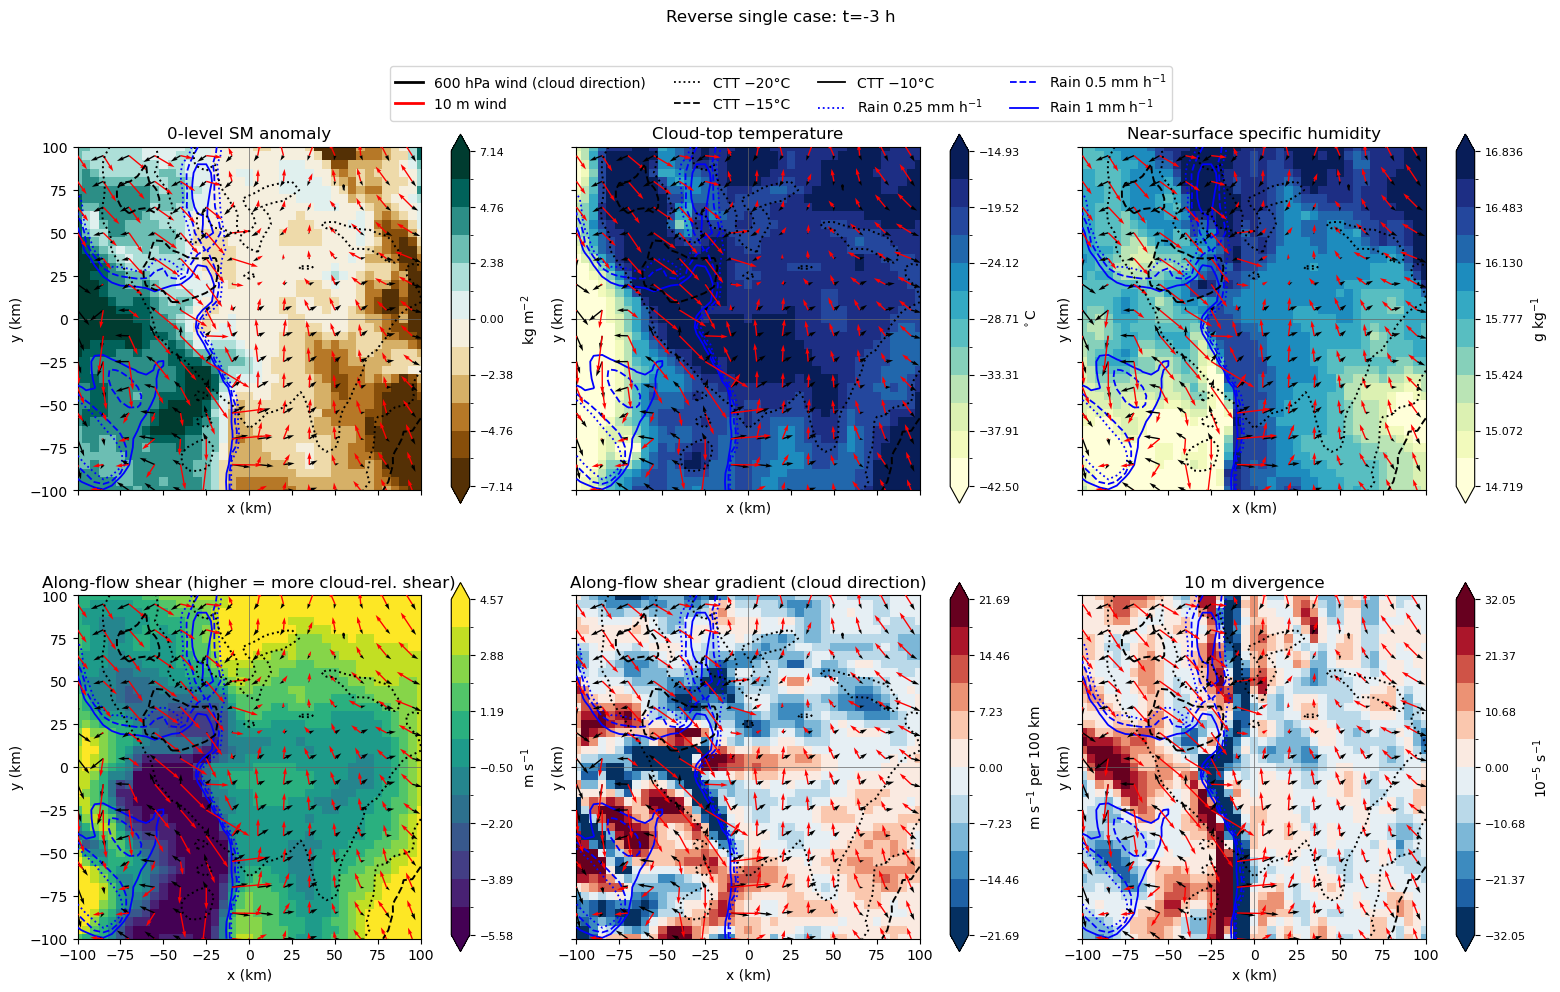

(<Figure size 1550x900 with 12 Axes>,
 array([[<Axes: title={'center': '0-level SM anomaly'}, xlabel='x (km)', ylabel='y (km)'>,
         <Axes: title={'center': 'Cloud-top temperature'}, xlabel='x (km)', ylabel='y (km)'>,
         <Axes: title={'center': 'Near-surface specific humidity'}, xlabel='x (km)', ylabel='y (km)'>],
        [<Axes: title={'center': 'Along-flow shear (higher = more cloud-rel. shear)'}, xlabel='x (km)', ylabel='y (km)'>,
         <Axes: title={'center': 'Along-flow shear gradient (cloud direction)'}, xlabel='x (km)', ylabel='y (km)'>,
         <Axes: title={'center': '10 m divergence'}, xlabel='x (km)', ylabel='y (km)'>]],
       dtype=object))

In [147]:
plotting_single_case(
    test_rotated=test_rotated,
    direction='reverse',
    lag=-3,
    X=X,
    Y=Y,
    output_file='example1_reverse_-3h.jpg'
)

In [70]:
N_PER_DIRECTION = 30
RANDOM_SEED = 42
direction_order = ['aligned', 'right', 'reverse', 'left']

sample_parts = []

for category_index, category in enumerate(direction_order):
    category_cases = filtered_cases[
        filtered_cases['category'] == category
    ].drop_duplicates(
        ['lon', 'lat', 'time']
    )

    for hour_index, hour in enumerate(CI_HOURS):
        hour_cases = category_cases[category_cases['hour'] == hour]
        n = N_PER_DIRECTION // len(CI_HOURS)

        sample_parts.append(
            hour_cases.sample(
                n=min(n, len(hour_cases)),
                random_state=RANDOM_SEED + category_index * 10 + hour_index
            )
        )

test_sample = pd.concat(sample_parts, ignore_index=True)

print(test_sample.groupby(['category', 'hour']).size().unstack(fill_value=0))

hour      14
category    
aligned   30
left      30
reverse   30
right     30


In [71]:
COMPOSITE_FIELDS = [
    'sm_anomaly', 'q_low', 
    'shear', 'div10',
    'u10', 'v10', 'u600', 'v600', 'ctt', 'rain'
]

composites = {}
failures = []

for category in direction_order:
    category_cases = test_sample[
        test_sample['category'] == category
    ]

    sums = {
        name: np.zeros_like(X, dtype=float)
        for name in COMPOSITE_FIELDS
    }
    counts = {
        name: np.zeros_like(X, dtype=np.int32)
        for name in COMPOSITE_FIELDS
    }

    successful = 0

    for number, (_, case) in enumerate(
        category_cases.iterrows(), start=1
    ):
        print('Doing', number)
        try:
            target_time = case['sample_time']

            case_fields = {}
            for variable in VARIABLES:
                cube, _ = load_field_at_time(variable, target_time)
                case_fields[variable] = cube

            rotated = process_one_case(case, case_fields)

            for name in COMPOSITE_FIELDS:
                data = rotated[name]
                valid = np.isfinite(data)
                sums[name][valid] += data[valid]
                counts[name][valid] += 1

            successful += 1

        except Exception as exc:
            failures.append({
                'category': category,
                'time': case['time'],
                'lon': case['lon'],
                'lat': case['lat'],
                'error': str(exc)
            })

        if number % 10 == 0 or number == len(category_cases):
            print(
                f'{category:8s}: processed {number:2d}/'
                f'{len(category_cases)}, successful={successful}'
            )

    means = {
        name: np.divide(
            sums[name], counts[name],
            out=np.full_like(sums[name], np.nan),
            where=counts[name] > 0
        )
        for name in COMPOSITE_FIELDS
    }

    composites[category] = {
        'mean': means,
        'count': counts,
        'n_cases': successful
    }

print(f'\nFailed cases: {len(failures)}')

if failures:
    display(pd.DataFrame(failures).head(20))

Doing 1


/home/users/cornkle/miniforge3/envs/work/lib/python3.14/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/users/cornkle/miniforge3/envs/work/lib/python3.14/site-packages/iris/fileformats/rules.py:382: IrisUserWarning: Unable to create instance of HybridHeightFactory. The source data contains no field(s) for 'orography'.
  warnings.warn(


Doing 2
Doing 3
Doing 4
Doing 5
Doing 6
Doing 7
Doing 8
Doing 9
Doing 10
aligned : processed 10/30, successful=10
Doing 11
Doing 12
Doing 13
Doing 14
Doing 15
Doing 16
Doing 17
Doing 18
Doing 19
Doing 20
aligned : processed 20/30, successful=20
Doing 21
Doing 22
Doing 23
Doing 24
Doing 25
Doing 26
Doing 27
Doing 28
Doing 29
Doing 30
aligned : processed 30/30, successful=30
Doing 1


/home/users/cornkle/miniforge3/envs/work/lib/python3.14/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/users/cornkle/miniforge3/envs/work/lib/python3.14/site-packages/iris/fileformats/rules.py:382: IrisUserWarning: Unable to create instance of HybridHeightFactory. The source data contains no field(s) for 'orography'.
  warnings.warn(


Doing 2
Doing 3
Doing 4
Doing 5
Doing 6
Doing 7
Doing 8
Doing 9
Doing 10
right   : processed 10/30, successful=10
Doing 11
Doing 12
Doing 13
Doing 14
Doing 15
Doing 16
Doing 17
Doing 18
Doing 19
Doing 20
right   : processed 20/30, successful=20
Doing 21
Doing 22
Doing 23
Doing 24
Doing 25
Doing 26
Doing 27
Doing 28
Doing 29
Doing 30
right   : processed 30/30, successful=30
Doing 1


/home/users/cornkle/miniforge3/envs/work/lib/python3.14/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/users/cornkle/miniforge3/envs/work/lib/python3.14/site-packages/iris/fileformats/rules.py:382: IrisUserWarning: Unable to create instance of HybridHeightFactory. The source data contains no field(s) for 'orography'.
  warnings.warn(


Doing 2
Doing 3
Doing 4
Doing 5
Doing 6
Doing 7
Doing 8
Doing 9
Doing 10
reverse : processed 10/30, successful=10
Doing 11
Doing 12
Doing 13
Doing 14
Doing 15
Doing 16
Doing 17
Doing 18
Doing 19
Doing 20
reverse : processed 20/30, successful=20
Doing 21
Doing 22
Doing 23
Doing 24
Doing 25
Doing 26
Doing 27
Doing 28
Doing 29
Doing 30
reverse : processed 30/30, successful=30
Doing 1


/home/users/cornkle/miniforge3/envs/work/lib/python3.14/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)
/home/users/cornkle/miniforge3/envs/work/lib/python3.14/site-packages/iris/fileformats/rules.py:382: IrisUserWarning: Unable to create instance of HybridHeightFactory. The source data contains no field(s) for 'orography'.
  warnings.warn(


Doing 2
Doing 3
Doing 4
Doing 5
Doing 6
Doing 7
Doing 8
Doing 9
Doing 10
left    : processed 10/30, successful=10
Doing 11
Doing 12
Doing 13
Doing 14
Doing 15
Doing 16
Doing 17
Doing 18
Doing 19
Doing 20
left    : processed 20/30, successful=20
Doing 21
Doing 22
Doing 23
Doing 24
Doing 25
Doing 26
Doing 27
Doing 28
Doing 29
Doing 30
left    : processed 30/30, successful=30

Failed cases: 0


In [43]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm

def plot_direction_composites(
    variable, title, cmap, colorbar_label,
    symmetric=False, factor=1,
    quiver_step=10, quiver_scale=180
):
    plotted = {
        category: composites[category]['mean'][variable] * factor
        for category in direction_order
    }

    values = np.concatenate([
        data[np.isfinite(data)]
        for data in plotted.values()
    ])

    if symmetric:
        limit = np.nanpercentile(np.abs(values), 98)
        norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
        plotting_kwargs = {'norm': norm}
    else:
        vmin, vmax = np.nanpercentile(values, [2, 98])
        plotting_kwargs = {'vmin': vmin, 'vmax': vmax}

    fig, axes = plt.subplots(
        1, 4, figsize=(17, 4.4),
        sharex=True, sharey=True,
        constrained_layout=True
    )

    for ax, category in zip(axes, direction_order):
        mean = composites[category]['mean']

        shading = ax.pcolormesh(
            X, Y, plotted[category],
            cmap=cmap, shading='auto',
            **plotting_kwargs
        )

                # CTT contours on every panel
        ctt_contours = ax.contour(
            X, Y, test_rotated['ctt'],
            levels=[-30, -20],
            colors='black',
            linestyles=['--', '-'],
            linewidths=1.3,
            zorder=3
        )
    
        ax.clabel(
            ctt_contours,
            fmt={-30: '−30', -20: '−20'},
            fontsize=8,
            inline=True
        )
    
        # Rain contours on every panel
        rain_contours = ax.contour(
            X, Y, test_rotated['rain'],
            levels=[1, 5],
            colors='blue',
            linestyles=['--', '-'],
            linewidths=1.3,
            zorder=3
        )
    
        ax.clabel(
            ctt_contours,
            fmt={1: '1', 2: '2'},
            fontsize=8,
            inline=True
        )

        ax.quiver(
            X[::quiver_step, ::quiver_step],
            Y[::quiver_step, ::quiver_step],
            mean['u600'][::quiver_step, ::quiver_step],
            mean['v600'][::quiver_step, ::quiver_step],
            color='black', scale=quiver_scale, width=0.003
        )

        ax.quiver(
            X[::quiver_step, ::quiver_step],
            Y[::quiver_step, ::quiver_step],
            mean['u10'][::quiver_step, ::quiver_step],
            mean['v10'][::quiver_step, ::quiver_step],
            color='red', scale=quiver_scale, width=0.003
        )

        ax.plot(0, 0, '+', color='magenta', ms=11, mew=2)
        ax.axhline(0, color='0.4', lw=0.5)
        ax.axvline(0, color='0.4', lw=0.5)

        ax.set(
            title=f'{category.capitalize()} '
                  f'(n={composites[category]["n_cases"]})',
            xlabel='x (km)',
            xlim=(-HALF_WIDTH_KM, HALF_WIDTH_KM),
            ylim=(-HALF_WIDTH_KM, HALF_WIDTH_KM),
            aspect='equal'
        )

    axes[0].set_ylabel('y (km)')
    fig.suptitle(title)

    handles = [
        Line2D([0], [0], color='black', lw=2, label='600 hPa wind'),
        Line2D([0], [0], color='red', lw=2, label='10 m wind')
    ]
    fig.legend(handles=handles, loc='upper center', ncol=2)
    fig.colorbar(
        shading, ax=axes.tolist(),
        label=colorbar_label, shrink=0.82
    )

    plt.show()

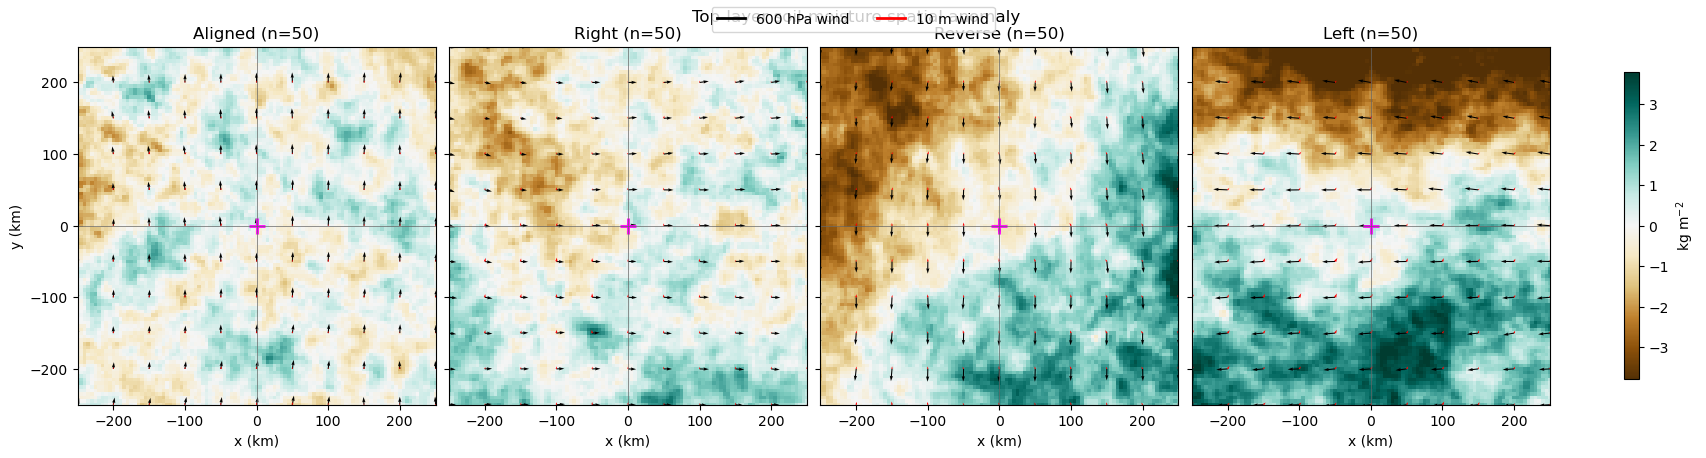

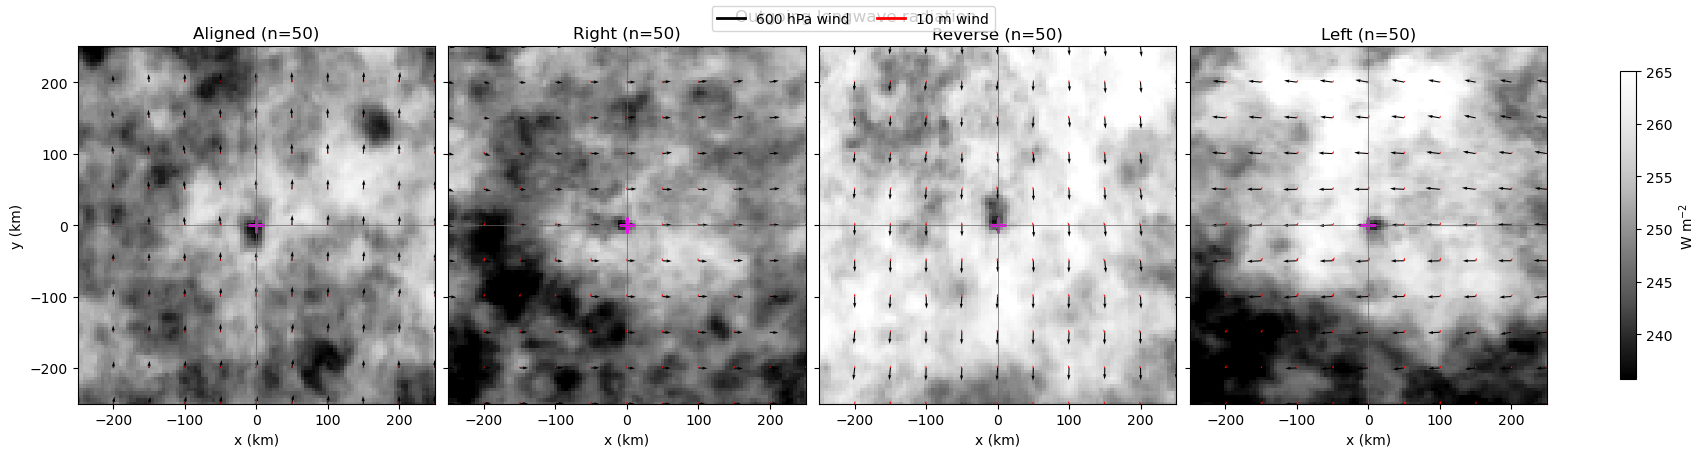

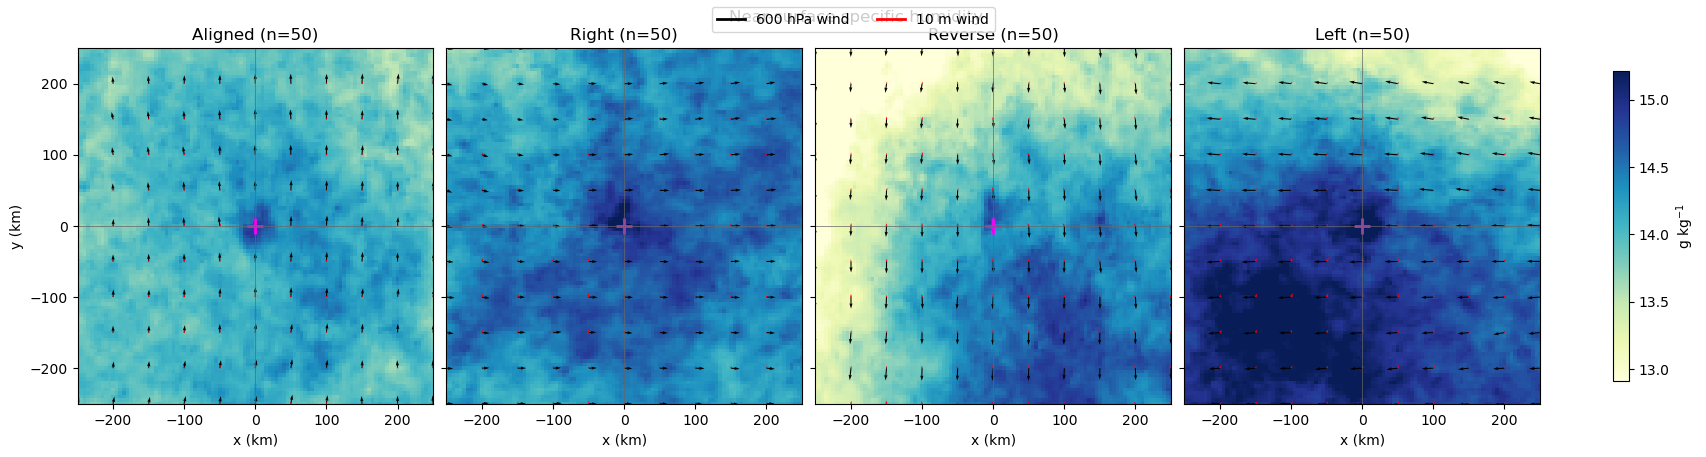

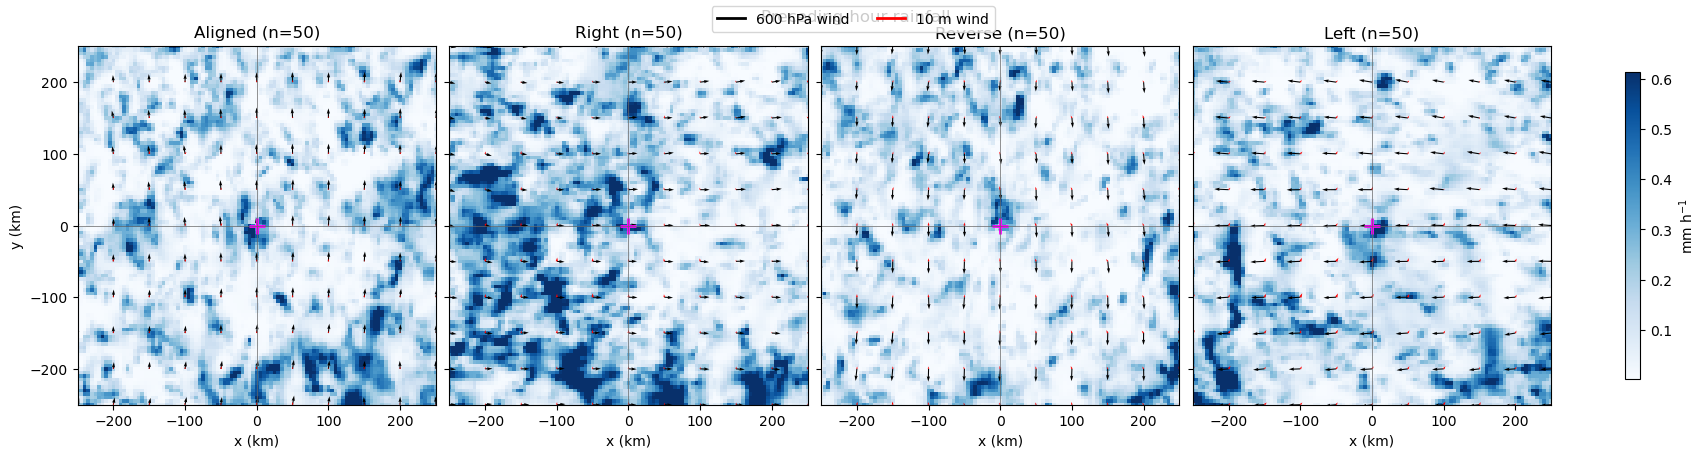

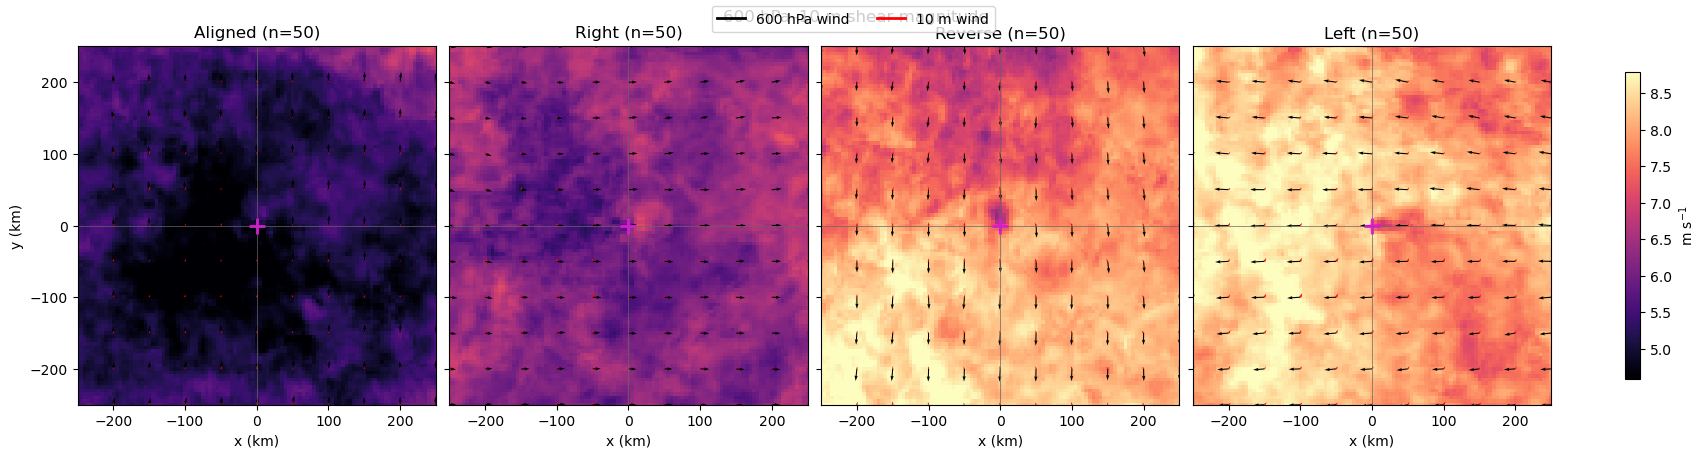

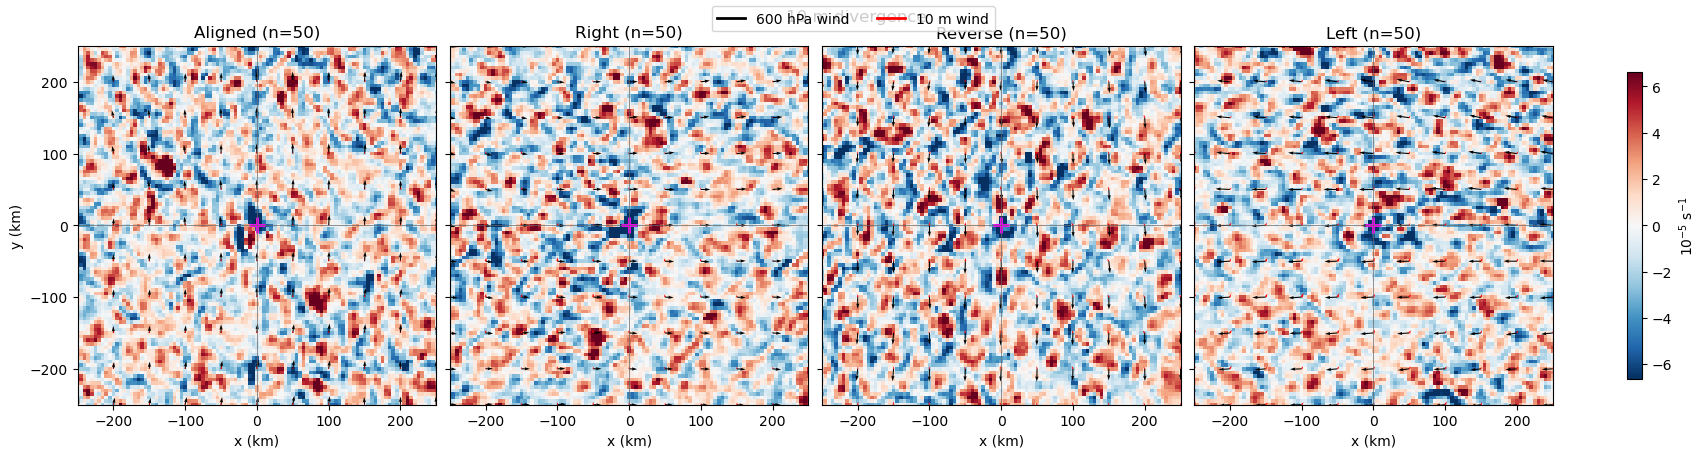

In [44]:
plot_direction_composites(
    'sm_anomaly',
    'Top-layer soil-moisture spatial anomaly',
    'BrBG', r'kg m$^{-2}$',
    symmetric=True
)

plot_direction_composites(
    'olr',
    'Outgoing longwave radiation',
    'Greys_r', r'W m$^{-2}$'
)

plot_direction_composites(
    'q_low',
    'Near-surface specific humidity',
    'YlGnBu', r'g kg$^{-1}$'
)

plot_direction_composites(
    'rain',
    'Preceding-hour rainfall',
    'Blues', r'mm h$^{-1}$'
)

plot_direction_composites(
    'shear',
    '600 hPa–10 m shear magnitude',
    'magma', r'm s$^{-1}$'
)

plot_direction_composites(
    'div10',
    '10 m divergence',
    'RdBu_r', r'$10^{-5}$ s$^{-1}$',
    symmetric=True, factor=1e5
)